# Comparaison VAE Conditionnel vs Modèle de Diffusion (DDPM)
## Validation statistique sur 100 répétitions d'inférence

**Architecture :**
- Entraînement sur la **magnitude** de l'accéléromètre (1D)
- Évaluation avec les **3 axes** (X, Y, Z) — les juges sont entraînés sur la magnitude
- Les juges sont entraînés **une seule fois** sur les données réelles
- Métriques : score juges, **ElderNet Gait Score** (autocorrélation + cadence + régularité)
- **100 répétitions d'inférence** → tests statistiques (Wilcoxon signed-rank, bootstrap CI)

In [1]:
import gc
import sys
import os
import copy
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy import signal as scipy_signal
from scipy.stats import wilcoxon, bootstrap
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset

# =========================================================
# 1. CONFIGURATION
# =========================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("===== DEBUG PYTHON / CUDA =====")
print("Python executable:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. This script requires a GPU."
    )

device = torch.device("cuda:0")
print("Device utilisé :", device)
print("GPU utilisée :", torch.cuda.get_device_name(0))
print("================================")

# ── Chemin du fichier parquet ───────────────────────────────────────────────
path = r"C:\Users\adril\Downloads\unified_dataset_filtered_4_balanced.parquet"

# ── Hyper-paramètres fenêtrage ───────────────────────────────────────────────
WINDOW_SIZE   = 50
STRIDE        = 25
BATCH_SIZE    = 4096
FS            = 50          # fréquence d'échantillonnage (Hz)

# ── VAE ──────────────────────────────────────────────────────────────────────
VAE_EPOCHS    = 50
LATENT_DIM    = 32
LABEL_EMB_DIM = 16

# ── Diffusion ────────────────────────────────────────────────────────────────
DIFF_EPOCHS   = 50
N_STEPS       = 200
TIME_EMB_DIM  = 32

# ── Juges ────────────────────────────────────────────────────────────────────
JUDGE_EPOCHS  = 30

# ── Évaluation statistique ───────────────────────────────────────────────────
N_INFERENCE_RUNS = 100   # répétitions d'inférence pour les stats
N_GEN_PER_RUN    = 30    # fenêtres générées par run et par classe

===== DEBUG PYTHON / CUDA =====
Python executable: D:\IMDS\MALMO\.venv\Scripts\python.exe
Torch version: 2.6.0+cu124
CUDA available: True
Device utilisé : cuda:0
GPU utilisée : NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# =========================================================
# 2. CHARGEMENT — MAGNITUDE (entraînement) + 3 AXES (évaluation)
# =========================================================
# Dataset : unified_dataset_filtered_4_balanced.parquet
#   Labels : 0=rest_inactive  2=walk  3=run_jog  4=stairs
#   Données déjà normalisées par label (StandardScaler appliqué en amont)
#   Fréquence : 50 Hz
#
# On calcule la magnitude sur les 3 axes normalisés.
# X_mag  (1 canal)  → entraînement VAE / Diffusion / GAN / Juges
# X_3ax  (3 canaux) → analyse physique / ElderNet gait score

X_mag  = []
X_3ax  = []
labels = []
groups = []

parquet_file = pq.ParquetFile(path)
print(f"Nombre de paquets à traiter : {parquet_file.num_row_groups}")

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "acc_x", "acc_y", "acc_z",
            "global_activity_id", "dataset", "subject_id", "session_id",
        ],
    ).to_pandas()

    acc_mag = np.sqrt(
        chunk["acc_x"].values**2
        + chunk["acc_y"].values**2
        + chunk["acc_z"].values**2
    ).astype(np.float32)

    chunk["acc_mag"] = acc_mag

    for gk, gdf in chunk.groupby(["dataset", "subject_id", "session_id"]):
        mag_sig = gdf["acc_mag"].values.astype(np.float32)
        ax_sig  = gdf[["acc_x", "acc_y", "acc_z"]].values.astype(np.float32)
        acts    = gdf["global_activity_id"].values

        if len(mag_sig) < WINDOW_SIZE:
            continue

        for j in range(0, len(mag_sig) - WINDOW_SIZE + 1, STRIDE):
            X_mag.append(mag_sig[j: j + WINDOW_SIZE])
            X_3ax.append(ax_sig[j: j + WINDOW_SIZE])
            lbl = Counter(acts[j: j + WINDOW_SIZE]).most_common(1)[0][0]
            labels.append(lbl)
            groups.append(str(gk))

    del chunk
    gc.collect()

    if (i + 1) % 5 == 0:
        print(f"Paquet {i + 1}/{parquet_file.num_row_groups} terminé...")

X_mag  = np.asarray(X_mag,  dtype=np.float32)   # (N, 50)
X_3ax  = np.asarray(X_3ax,  dtype=np.float32)   # (N, 50, 3)
labels = np.asarray(labels)
groups = np.asarray(groups)

print(f"Chargement terminé. Fenêtres : {len(X_mag)}")
print("Distribution des labels :")
for lbl, name in {0:'rest_inactive', 2:'walk', 3:'run_jog', 4:'stairs'}.items():
    n = np.sum(labels == lbl)
    if n > 0:
        print(f"  [{lbl}] {name} : {n:,} fenêtres")


Nombre de paquets à traiter : 6
Paquet 5/6 terminé...
Chargement terminé. Fenêtres : 220915
Distribution des labels :
  [0] rest_inactive : 83,590 fenêtres
  [2] walk : 61,627 fenêtres
  [3] run_jog : 54,110 fenêtres
  [4] stairs : 21,588 fenêtres


In [3]:
# =========================================================
# 3. MAPPING DES LABELS
# =========================================================

unique_labels     = sorted(np.unique(labels))
label_mapping     = {old: new for new, old in enumerate(unique_labels)}
inv_label_mapping = {new: old for old, new in label_mapping.items()}
labels_mapped     = np.asarray([label_mapping[l] for l in labels], dtype=np.int64)
n_classes         = len(unique_labels)

print("Mapping des labels :")
for old, new in label_mapping.items():
    print(f"  {old} → {new}")
print(f"Nombre de classes : {n_classes}")

Mapping des labels :
  0 → 0
  2 → 1
  3 → 2
  4 → 3
Nombre de classes : 4


In [4]:
# =========================================================
# 4. SPLIT TRAIN / VAL / TEST PAR SESSION (stratifié groupe)
# =========================================================

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(X_mag, labels_mapped, groups=groups))

X_mag_tv = X_mag[train_val_idx];  y_tv = labels_mapped[train_val_idx]
g_tv     = groups[train_val_idx]
X_3ax_tv = X_3ax[train_val_idx]

X_mag_test = X_mag[test_idx];    y_test = labels_mapped[test_idx]
X_3ax_test = X_3ax[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2222, random_state=SEED)
tr_idx, va_idx = next(gss_val.split(X_mag_tv, y_tv, groups=g_tv))

X_mag_train = X_mag_tv[tr_idx];  y_train = y_tv[tr_idx]
X_3ax_train = X_3ax_tv[tr_idx]

X_mag_val   = X_mag_tv[va_idx];  y_val   = y_tv[va_idx]
X_3ax_val   = X_3ax_tv[va_idx]

print(f"Train : {len(X_mag_train)}   Val : {len(X_mag_val)}   Test : {len(X_mag_test)}")

Train : 160575   Val : 47038   Test : 13302


In [5]:
# =========================================================
# 5. NORMALISATION (z-score calculé sur train uniquement)
# =========================================================

mag_mean = np.mean(X_mag_train)
mag_std  = np.std(X_mag_train)
print(f"Magnitude — Mean: {mag_mean:.6f}  Std: {mag_std:.6f}")

def norm_mag(x):
    return (x - mag_mean) / (mag_std + 1e-8)

def denorm_mag(x):
    return x * (mag_std + 1e-8) + mag_mean

# Normalisation magnitude
Xtn = norm_mag(X_mag_train)
Xvn = norm_mag(X_mag_val)
Xen = norm_mag(X_mag_test)

# Normalisation 3 axes (par axe, stats calculées sur train)
ax_mean = X_3ax_train.mean(axis=(0, 1), keepdims=True)   # (1,1,3)
ax_std  = X_3ax_train.std(axis=(0, 1), keepdims=True)

def norm_3ax(x):
    return (x - ax_mean) / (ax_std + 1e-8)

X_3ax_train_n = norm_3ax(X_3ax_train)
X_3ax_val_n   = norm_3ax(X_3ax_val)
X_3ax_test_n  = norm_3ax(X_3ax_test)

# ── Tenseurs PyTorch ────────────────────────────────────────────────────────

def to_t(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype)

# Magnitude : (N, 1, 50)
Xtn_t = to_t(Xtn).unsqueeze(1)
Xvn_t = to_t(Xvn).unsqueeze(1)
Xen_t = to_t(Xen).unsqueeze(1)

ytr_t = to_t(y_train, torch.long)
yva_t = to_t(y_val,   torch.long)
yte_t = to_t(y_test,  torch.long)

train_ds = TensorDataset(Xtn_t, ytr_t)
val_ds   = TensorDataset(Xvn_t, yva_t)
test_ds  = TensorDataset(Xen_t, yte_t)

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds)
test_loader  = make_loader(test_ds)

print("Tenseurs prêts.")

Magnitude — Mean: 1.512264  Std: 0.777263
Tenseurs prêts.


In [6]:
# =========================================================
# 6. MODÈLES GÉNÉRATIFS
# =========================================================

# ── 6a. VAE Conditionnel ────────────────────────────────────────────────────

class ConditionalVAE(nn.Module):
    def __init__(self, n_classes, latent_dim=32, label_emb_dim=16):
        super().__init__()
        self.n_classes    = n_classes
        self.latent_dim   = latent_dim
        self.label_emb    = nn.Embedding(n_classes, label_emb_dim)

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.ReLU(), nn.Flatten(),
        )
        enc_out = 128 * 12
        self.fc_mu     = nn.Linear(enc_out + label_emb_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_out + label_emb_dim, latent_dim)
        self.dec_input = nn.Linear(latent_dim + label_emb_dim, 128 * 13)

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 1, 5, padding=2),
        )

    def encode(self, x, y):
        h = self.encoder(x)
        ye = self.label_emb(y)
        hc = torch.cat([h, ye], 1)
        return self.fc_mu(hc), self.fc_logvar(hc)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, -10, 10)
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z, y):
        ye = self.label_emb(y)
        return self.decoder(self.dec_input(torch.cat([z, ye], 1)).view(-1, 128, 13))

    def forward(self, x, y):
        mu, lv = self.encode(x, y)
        return self.decode(self.reparameterize(mu, lv), y), mu, lv

    @torch.no_grad()
    def sample(self, n_samples, class_id, device):
        self.eval()
        y = torch.full((n_samples,), class_id, dtype=torch.long, device=device)
        z = torch.randn(n_samples, self.latent_dim, device=device)
        return self.decode(z, y)   # (n, 1, 50)


# ── 6b. Réseau de débruitage DDPM ───────────────────────────────────────────

class ConditionalDiffusionNet(nn.Module):
    def __init__(self, n_classes, signal_len=50,
                 time_emb_dim=32, label_emb_dim=16):
        super().__init__()
        self.label_emb  = nn.Embedding(n_classes, label_emb_dim)
        self.time_mlp   = nn.Sequential(
            nn.Linear(1, time_emb_dim), nn.ReLU(),
            nn.Linear(time_emb_dim, time_emb_dim), nn.ReLU(),
        )
        self.conv1 = nn.Conv1d(1, 64, 5, padding=2)
        self.conv2 = nn.Conv1d(64, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 64, 5, padding=2)
        self.conv4 = nn.Conv1d(64, 1,  5, padding=2)
        self.cond_project = nn.Linear(time_emb_dim + label_emb_dim, 64)
        self.relu = nn.ReLU()

    def forward(self, x, t_float, y):
        cond = torch.cat([self.time_mlp(t_float), self.label_emb(y)], 1)
        cp   = self.cond_project(cond).unsqueeze(-1)
        h    = self.relu(self.conv1(x)) + cp
        h    = self.relu(self.conv2(h)) + cp
        h    = self.relu(self.conv3(h))
        return self.conv4(h)


class DiffusionContext:
    def __init__(self, n_steps=200, signal_len=50, device="cpu"):
        self.n_steps    = n_steps
        self.device     = device
        self.beta       = torch.linspace(1e-4, 0.02, n_steps, device=device)
        self.alpha      = 1.0 - self.beta
        self.alpha_cp   = torch.cumprod(self.alpha, 0)

    def add_noise(self, x0, t):
        noise   = torch.randn_like(x0)
        t_flat  = t.view(-1).long()
        sa      = torch.sqrt(self.alpha_cp[t_flat]).view(-1,1,1)
        sm      = torch.sqrt(1 - self.alpha_cp[t_flat]).view(-1,1,1)
        return sa * x0 + sm * noise, noise

    @torch.no_grad()
    def sample(self, model, n_samples, class_id):
        model.eval()
        x = torch.randn(n_samples, 1, self.alpha_cp.shape[0]//self.n_steps * self.n_steps,
                        device=self.device)
        # Correction : utilise la taille du signal directement
        x = torch.randn(n_samples, 1, WINDOW_SIZE, device=self.device)
        y = torch.full((n_samples,), class_id, dtype=torch.long, device=self.device)

        for i in reversed(range(self.n_steps)):
            tf  = torch.full((n_samples, 1), i, dtype=torch.float32, device=self.device)
            pn  = model(x, tf, y)
            bt  = self.beta[i]
            sat = torch.sqrt(self.alpha[i])
            smt = torch.sqrt(1 - self.alpha_cp[i])
            mu  = (1/sat) * (x - (bt/smt) * pn)
            x   = mu + (torch.sqrt(bt) * torch.randn_like(x) if i > 0 else 0)
        return x   # (n, 1, 50)

print("Architectures définies.")

# ── 6c. GAN Conditionnel (WGAN-GP) ───────────────────────────────────────────

GAN_LATENT_DIM = 32
GAN_LABEL_EMB  = 16
GAN_EPOCHS     = 50
GAN_LR         = 1e-4
N_CRITIC       = 5
LAMBDA_GP      = 10.0


class ConditionalGenerator(nn.Module):
    def __init__(self, n_classes, latent_dim=32, label_emb_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.label_emb  = nn.Embedding(n_classes, label_emb_dim)
        self.dec_input  = nn.Linear(latent_dim + label_emb_dim, 128 * 13)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 1, 5, padding=2),
            nn.Tanh(),
        )

    def forward(self, z, y):
        ye = self.label_emb(y)
        h  = self.dec_input(torch.cat([z, ye], 1)).view(-1, 128, 13)
        return self.decoder(h)

    @torch.no_grad()
    def sample(self, n_samples, class_id, device):
        self.eval()
        z = torch.randn(n_samples, self.latent_dim, device=device)
        y = torch.full((n_samples,), class_id, dtype=torch.long, device=device)
        return self.forward(z, y)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_classes, label_emb_dim=16, signal_len=50):
        super().__init__()
        self.label_emb  = nn.Embedding(n_classes, label_emb_dim)
        self.label_proj = nn.Linear(label_emb_dim, signal_len)
        self.conv = nn.Sequential(
            nn.Conv1d(2, 64,  5, padding=2), nn.LeakyReLU(0.2),
            nn.Conv1d(64, 128, 3, padding=1), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x, y):
        ye = self.label_emb(y)
        yp = self.label_proj(ye).unsqueeze(1)
        return self.fc(self.conv(torch.cat([x, yp], 1)))


def gradient_penalty(disc, real, fake, y, device):
    N   = real.size(0)
    eps = torch.rand(N, 1, 1, device=device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    d_out  = disc(interp, y)
    grads  = torch.autograd.grad(d_out, interp,
                                  grad_outputs=torch.ones_like(d_out),
                                  create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=[1, 2]) - 1) ** 2).mean()


def train_gan(generator, discriminator, loader, val_loader=None, epochs=GAN_EPOCHS):
    opt_G = optim.Adam(generator.parameters(),     lr=GAN_LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))

    for ep in range(epochs):
        generator.train(); discriminator.train()
        g_losses, d_losses = [], []

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            N = xb.size(0)

            # ── Discriminateur ──
            for _ in range(N_CRITIC):
                z    = torch.randn(N, GAN_LATENT_DIM, device=device)
                fake = generator(z, yb).detach()
                gp   = gradient_penalty(discriminator, xb, fake, yb, device)
                loss_D = discriminator(fake, yb).mean() - discriminator(xb, yb).mean() + LAMBDA_GP * gp
                opt_D.zero_grad(); loss_D.backward(); opt_D.step()
                d_losses.append(loss_D.item())

            # ── Générateur ──
            z      = torch.randn(N, GAN_LATENT_DIM, device=device)
            loss_G = -discriminator(generator(z, yb), yb).mean()
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()
            g_losses.append(loss_G.item())

        vl_str = ""
        if val_loader is not None:
            generator.eval(); discriminator.eval()
            vg = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    z = torch.randn(xb.size(0), GAN_LATENT_DIM, device=device)
                    vg.append(-discriminator(generator(z, yb), yb).mean().item())
            vl_str = f" | ValG {np.mean(vg):.4f}"

        print(f"GAN Ep {ep+1:03d} | G {np.mean(g_losses):.4f} | D {np.mean(d_losses):.4f}{vl_str}")

print("Architectures GAN + fonction d'entraînement définies.")


Architectures définies.
Architectures GAN + fonction d'entraînement définies.


In [7]:
# =========================================================
# 7. JUGES (entraînés UNE SEULE FOIS sur la magnitude)
# =========================================================

class DeepConvLSTM(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, 5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 64, 5, padding=2), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True)
        self.fc   = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        h, _ = self.lstm(self.conv(x).transpose(1,2))
        return self.fc(h[:, -1, :])


class CNNSimple(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 64, 3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)


class MLPSimple(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(WINDOW_SIZE, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def train_judge(model, train_loader, val_loader=None, epochs=JUDGE_EPOCHS):
    opt  = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        tot_loss = tot_corr = tot_n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss   = crit(logits, yb)
            if not torch.isfinite(loss): return
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_loss += loss.item() * xb.size(0)
            tot_corr += (logits.argmax(1) == yb).sum().item()
            tot_n    += xb.size(0)
        tl = tot_loss / tot_n;  ta = tot_corr / tot_n
        if val_loader is not None:
            vl, va = eval_judge(model, val_loader)
            print(f"[{model.__class__.__name__}] Ep {ep+1:03d} "
                  f"| TrLoss {tl:.4f} TrAcc {ta:.4f} "
                  f"| VaLoss {vl:.4f} VaAcc {va:.4f}")
        else:
            print(f"[{model.__class__.__name__}] Ep {ep+1:03d} "
                  f"| TrLoss {tl:.4f} TrAcc {ta:.4f}")


def eval_judge(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tot_loss = tot_corr = tot_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = crit(logits, yb)
            tot_loss += loss.item() * xb.size(0)
            tot_corr += (logits.argmax(1) == yb).sum().item()
            tot_n    += xb.size(0)
    return tot_loss / tot_n, tot_corr / tot_n


print("Architectures juges définies.")

Architectures juges définies.


In [8]:
# =========================================================
# 8. FONCTIONS D'ENTRAÎNEMENT — VAE ET DIFFUSION
# =========================================================

def train_vae(model, loader, val_loader=None, epochs=VAE_EPOCHS, beta=0.001):
    opt = optim.Adam(model.parameters(), lr=1e-4)
    for ep in range(epochs):
        model.train()
        tot_loss = tot_n = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            recon, mu, lv = model(xb, yb)
            lv = torch.clamp(lv, -10, 10)
            mse = nn.functional.mse_loss(recon, xb)
            kld = (-0.5 * (1 + lv - mu**2 - lv.exp()).sum(1)).mean()
            loss = mse + beta * kld
            if not torch.isfinite(loss): return
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_loss += loss.item() * xb.size(0)
            tot_n    += xb.size(0)
        tl = tot_loss / tot_n
        vl_str = ""
        if val_loader is not None:
            model.eval(); vtot = vn = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    recon, mu, lv = model(xb, yb)
                    lv = torch.clamp(lv, -10, 10)
                    mse = nn.functional.mse_loss(recon, xb)
                    kld = (-0.5*(1+lv-mu**2-lv.exp()).sum(1)).mean()
                    l   = mse + beta*kld
                    vtot += l.item()*xb.size(0); vn += xb.size(0)
            vl_str = f" | ValLoss {vtot/vn:.5f}"
        print(f"VAE Ep {ep+1:03d} | TrainLoss {tl:.5f}{vl_str}")


def train_diffusion(model, ctx, loader, val_loader=None, epochs=DIFF_EPOCHS):
    opt  = optim.Adam(model.parameters(), lr=1e-4)
    crit = nn.MSELoss()
    for ep in range(epochs):
        model.train()
        tot_loss = tot_n = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            t       = torch.randint(0, ctx.n_steps, (xb.size(0),), device=device)
            xt, eps = ctx.add_noise(xb, t)
            tf      = t.float().unsqueeze(-1)
            pred    = model(xt, tf, yb)
            loss    = crit(pred, eps)
            if not torch.isfinite(loss): return
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_loss += loss.item()*xb.size(0); tot_n += xb.size(0)
        tl = tot_loss / tot_n
        vl_str = ""
        if val_loader is not None:
            model.eval(); vtot = vn = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    t = torch.randint(0, ctx.n_steps, (xb.size(0),), device=device)
                    xt, eps = ctx.add_noise(xb, t)
                    tf = t.float().unsqueeze(-1)
                    l  = crit(model(xt, tf, yb), eps)
                    vtot += l.item()*xb.size(0); vn += xb.size(0)
            vl_str = f" | ValLoss {vtot/vn:.6f}"
        print(f"Diff Ep {ep+1:03d} | TrainLoss {tl:.6f}{vl_str}")

print("Fonctions d'entraînement définies.")

Fonctions d'entraînement définies.


In [9]:
# =========================================================
# 9. ENTRAÎNEMENT PRINCIPAL (une seule fois)
# =========================================================

# ── VAE ──────────────────────────────────────────────────────────────────────
vae_model = ConditionalVAE(n_classes, LATENT_DIM, LABEL_EMB_DIM).to(device)
print("\n🔵 Entraînement VAE conditionnel")
train_vae(vae_model, train_loader, val_loader, epochs=VAE_EPOCHS)

# ── Diffusion ────────────────────────────────────────────────────────────────
diff_model   = ConditionalDiffusionNet(n_classes, WINDOW_SIZE, TIME_EMB_DIM, LABEL_EMB_DIM).to(device)
diff_context = DiffusionContext(N_STEPS, WINDOW_SIZE, device)
print("\n🟠 Entraînement modèle de diffusion conditionnel")
train_diffusion(diff_model, diff_context, train_loader, val_loader, epochs=DIFF_EPOCHS)

# ── Juges (entraînés une seule fois sur données réelles magnitude) ───────────
judges = [
    DeepConvLSTM(n_classes).to(device),
    CNNSimple(n_classes).to(device),
    MLPSimple(n_classes).to(device),
]

for judge in judges:
    print(f"\n🟢 Entraînement Juge : {judge.__class__.__name__}")
    train_judge(judge, train_loader, val_loader, epochs=JUDGE_EPOCHS)

# Sauvegarde des états (optionnel mais pratique si on veut relancer l'éval)
for judge in judges:
    judge.eval()


# ── GAN conditionnel ──────────────────────────────────────────────────────────
gan_gen  = ConditionalGenerator(n_classes, GAN_LATENT_DIM, GAN_LABEL_EMB).to(device)
gan_disc = ConditionalDiscriminator(n_classes, GAN_LABEL_EMB, WINDOW_SIZE).to(device)
print("\n🟣 Entraînement GAN conditionnel (WGAN-GP)")
train_gan(gan_gen, gan_disc, train_loader, val_loader, epochs=GAN_EPOCHS)

print("\n✅ Entraînement terminé (VAE + Diffusion + GAN + Juges).")



🔵 Entraînement VAE conditionnel
VAE Ep 001 | TrainLoss 0.98368 | ValLoss 1.10432
VAE Ep 002 | TrainLoss 0.72357 | ValLoss 0.61471
VAE Ep 003 | TrainLoss 0.58017 | ValLoss 0.57037
VAE Ep 004 | TrainLoss 0.50455 | ValLoss 0.43860
VAE Ep 005 | TrainLoss 0.32215 | ValLoss 0.29351
VAE Ep 006 | TrainLoss 0.24845 | ValLoss 0.25931
VAE Ep 007 | TrainLoss 0.22133 | ValLoss 0.23062
VAE Ep 008 | TrainLoss 0.19835 | ValLoss 0.20921
VAE Ep 009 | TrainLoss 0.18101 | ValLoss 0.19135
VAE Ep 010 | TrainLoss 0.16662 | ValLoss 0.17628
VAE Ep 011 | TrainLoss 0.15427 | ValLoss 0.16370
VAE Ep 012 | TrainLoss 0.14490 | ValLoss 0.15550
VAE Ep 013 | TrainLoss 0.13872 | ValLoss 0.14982
VAE Ep 014 | TrainLoss 0.13387 | ValLoss 0.14525
VAE Ep 015 | TrainLoss 0.13005 | ValLoss 0.14182
VAE Ep 016 | TrainLoss 0.12704 | ValLoss 0.13886
VAE Ep 017 | TrainLoss 0.12424 | ValLoss 0.13561
VAE Ep 018 | TrainLoss 0.12152 | ValLoss 0.13305
VAE Ep 019 | TrainLoss 0.11914 | ValLoss 0.13031
VAE Ep 020 | TrainLoss 0.11687 | Val

In [10]:
# =========================================================
# 10. ELDERNET GAIT SCORE
# =========================================================
# Inspiré de Brand et al. 2026 (npj Digital Medicine).
# Le score combine :
#   (a) autocorrélation (régularité de la foulée)
#   (b) cadence estimée (autocorrélation + pic dominant)
#   (c) entropie spectrale (inversée = régularité fréquentielle)
#
# Les 3 axes sont utilisés ici pour enrichir l'analyse.
# Le signal de référence pour l'autocorrélation est la magnitude
# dénormalisée (comme dans ElderNet) ou le signal 3D.

def eldernet_gait_score(signal_norm_np, fs=FS, return_details=False):
    """
    signal_norm_np : (1, L) numpy array — signal normalisé magnitude
    Retourne un score scalaire [0, 1] :
        0 = signal apériodique (repos)
        1 = signal très périodique (marche régulière)
    Optionnel : return_details=True renvoie (score, cadence_spm, regularity)
    """
    mag = denorm_mag(signal_norm_np).flatten().astype(np.float64)
    mag = mag - np.mean(mag)

    # ── Autocorrélation normalisée ────────────────────────────────────────────
    corr = np.correlate(mag, mag, mode="full")[len(mag) - 1:]
    corr = corr / (corr[0] + 1e-9)

    # Pic dominant dans la plage marche humaine [0.4s – 1.2s]
    min_lag = max(1, int(0.4 * fs))
    max_lag = min(len(corr) - 1, int(1.2 * fs))

    if max_lag > min_lag:
        best_lag  = np.argmax(corr[min_lag:max_lag]) + min_lag
        regularity = float(corr[best_lag])
        step_time  = best_lag / fs          # secondes
        cadence    = 60.0 / (step_time + 1e-9)  # pas/min
        # Borne cadence physiologique [40 – 160 spm]
        cadence = float(np.clip(cadence, 40, 160))
    else:
        regularity = 0.0
        cadence    = 0.0

    # ── Entropie spectrale (mesure de la complexité fréquentielle) ────────────
    freqs, psd = scipy_signal.periodogram(mag, fs=fs)
    psd_norm   = psd / (psd.sum() + 1e-9)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-9))
    max_entropy = np.log2(len(psd_norm) + 1e-9)
    inv_entropy  = 1.0 - (spectral_entropy / (max_entropy + 1e-9))  # [0,1] — ↑ = plus organisé

    # ── Score composite ───────────────────────────────────────────────────────
    reg_clipped = float(np.clip(regularity, 0, 1))
    cadence_score = float(np.clip((cadence - 40) / 120, 0, 1))  # normalise [40,160]→[0,1]
    score = 0.5 * reg_clipped + 0.3 * inv_entropy + 0.2 * cadence_score

    if return_details:
        return score, cadence, reg_clipped
    return score


def eldernet_gait_score_3ax(windows_3ax_norm, fs=FS):
    """
    windows_3ax_norm : (N, L, 3) numpy array normalisé
    Retourne le score moyen sur les 3 axes (comme décrit dans l'article :
    ElderNet utilise le signal triaxial pour améliorer la robustesse).
    """
    scores = []
    for win in windows_3ax_norm:            # win : (L, 3)
        for ax_idx in range(3):             # X, Y, Z
            ax_sig = win[:, ax_idx]         # (L,)
            # Dénormali
            ax_denorm = ax_sig * (ax_std[0, 0, ax_idx] + 1e-8) + ax_mean[0, 0, ax_idx]
            ax_denorm  = ax_denorm - np.mean(ax_denorm)
            corr = np.correlate(ax_denorm, ax_denorm, mode="full")[len(ax_denorm)-1:]
            corr = corr / (corr[0] + 1e-9)
            min_lag = max(1, int(0.4*fs)); max_lag = min(len(corr)-1, int(1.2*fs))
            if max_lag > min_lag:
                best_lag = np.argmax(corr[min_lag:max_lag]) + min_lag
                reg = float(np.clip(corr[best_lag], 0, 1))
            else:
                reg = 0.0
            scores.append(reg)
    return float(np.mean(scores)) if scores else 0.0

print("ElderNet Gait Score défini.")

ElderNet Gait Score défini.


In [11]:
# =========================================================
# 11. FONCTIONS D'ÉVALUATION PAR INFÉRENCE
# =========================================================

@torch.no_grad()
def judge_score_batch(gen_tensor, true_label_mapped):
    """
    gen_tensor : (N, 1, L) — déjà sur device, normalisé magnitude
    Retourne la confiance moyenne et l'accuracy pour chaque juge.
    """
    results = {}
    for judge in judges:
        judge.eval()
        logits = judge(gen_tensor)
        probs  = torch.softmax(logits, 1)
        preds  = probs.argmax(1).cpu().numpy()
        confs  = probs.max(1).values.cpu().numpy()
        acc    = (preds == true_label_mapped).mean()
        conf   = confs.mean()
        results[judge.__class__.__name__] = dict(acc=float(acc), conf=float(conf))
    return results


def single_inference_run(model_type, class_id_mapped, n_samples=N_GEN_PER_RUN):
    """
    Effectue une inférence pour un modèle donné, retourne un dict de métriques.
    model_type : 'vae', 'diff' ou 'gan'
    class_id_mapped : label mappé (0, 1 ou 2)
    """
    if model_type == 'vae':
        gen = vae_model.sample(n_samples, class_id_mapped, device)
    elif model_type == 'diff':
        gen = diff_context.sample(diff_model, n_samples, class_id_mapped)
    else:  # gan
        gen = gan_gen.sample(n_samples, class_id_mapped, device)

    gen_np = gen.cpu().numpy()   # (N, 1, 50) normalisé

    # Score juges (sur magnitude normalisée, entrée standard des juges)
    judge_res = judge_score_batch(gen, class_id_mapped)

    # ElderNet Gait Score sur la magnitude générée
    gait_scores_mag = [eldernet_gait_score(gen_np[i], FS) for i in range(n_samples)]
    mean_gait_mag   = float(np.mean(gait_scores_mag))

    return dict(
        judge_res      = judge_res,
        gait_score_mag = mean_gait_mag,
    )


print("Fonctions d'évaluation définies.")

Fonctions d'évaluation définies.


In [12]:
# =========================================================
# 12. BOUCLE 100 RÉPÉTITIONS D'INFÉRENCE
# =========================================================
#
# Pour chaque classe × modèle × run :
#   - score de chaque juge (accuracy + confiance)
#   - ElderNet Gait Score (magnitude)
#

print(f"Lancement de {N_INFERENCE_RUNS} répétitions d'inférence...")

# Structure : results[model][class_mapped] = list de métriques sur N_INFERENCE_RUNS
results = {model: {c: [] for c in range(n_classes)} for model in ['vae', 'diff', 'gan']}

for run in range(N_INFERENCE_RUNS):
    for cls in range(n_classes):
        for mtype in ['vae', 'diff', 'gan']:
            res = single_inference_run(mtype, cls, N_GEN_PER_RUN)
            results[mtype][cls].append(res)

    if (run + 1) % 10 == 0:
        print(f"  Run {run+1}/{N_INFERENCE_RUNS} terminé")

print("✅ 100 runs terminés.")

Lancement de 100 répétitions d'inférence...
  Run 10/100 terminé
  Run 20/100 terminé
  Run 30/100 terminé
  Run 40/100 terminé
  Run 50/100 terminé
  Run 60/100 terminé
  Run 70/100 terminé
  Run 80/100 terminé
  Run 90/100 terminé
  Run 100/100 terminé
✅ 100 runs terminés.


In [13]:
# =========================================================
# 13. AGRÉGATION ET TESTS STATISTIQUES
# =========================================================
#
# Test de Wilcoxon signé bilatéral (non-paramétrique) pour chaque métrique.
# Intervalles de confiance à 95 % par bootstrap.
#

from scipy.stats import wilcoxon

judge_names = [j.__class__.__name__ for j in judges]

# ── Helpers ──────────────────────────────────────────────────────────────────

def extract_series(model_type, cls, metric_fn):
    """Renvoie la liste (N_INFERENCE_RUNS,) d'une métrique scalaire."""
    return [metric_fn(r) for r in results[model_type][cls]]

def bootstrap_ci(data, n_boot=2000, ci=0.95):
    data = np.array(data)
    boots = np.array([np.mean(np.random.choice(data, len(data))) for _ in range(n_boot)])
    lo = np.percentile(boots, 100*(1-ci)/2)
    hi = np.percentile(boots, 100*(1-(1-ci)/2))
    return lo, hi

def wilcox_test(a, b):
    """Wilcoxon signed-rank test (bilatéral). Retourne (statistic, p_value)."""
    try:
        stat, pval = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, pval = float('nan'), float('nan')
    return stat, pval


# ── Collecte des données ─────────────────────────────────────────────────────

# Métriques extraites pour chaque run / classe / modèle
summary_rows = []

for cls in range(n_classes):
    old_label = inv_label_mapping[cls]
    label_name = {0: 'rest_inactive', 2: 'walk', 3: 'run_jog', 4: 'stairs'}.get(old_label, f'Label {old_label}')

    # Gait score — comparaison 3 paires
    gait_vae  = extract_series('vae',  cls, lambda r: r['gait_score_mag'])
    gait_diff = extract_series('diff', cls, lambda r: r['gait_score_mag'])
    gait_gan  = extract_series('gan',  cls, lambda r: r['gait_score_mag'])

    for (pair, s1, s2, n1, n2) in [
        ('VAE_vs_Diff', gait_vae, gait_diff, 'VAE',       'Diffusion'),
        ('VAE_vs_GAN',  gait_vae, gait_gan,  'VAE',       'GAN'),
        ('Diff_vs_GAN', gait_diff, gait_gan, 'Diffusion', 'GAN'),
    ]:
        stat, pval = wilcox_test(s1, s2)
        summary_rows.append(dict(
            label=label_name, metric=f'GaitScore({pair})',
            vae_mean=np.mean(s1),   vae_std=np.std(s1),
            vae_ci_lo=bootstrap_ci(s1)[0], vae_ci_hi=bootstrap_ci(s1)[1],
            diff_mean=np.mean(s2),  diff_std=np.std(s2),
            diff_ci_lo=bootstrap_ci(s2)[0], diff_ci_hi=bootstrap_ci(s2)[1],
            wilcox_stat=stat, p_value=pval,
            better=n1 if np.mean(s1) > np.mean(s2) else n2
        ))

    # Juges — accuracy et confiance — 3 paires
    for jname in judge_names:
        for metric_key, label_str in [('acc', 'JudgeAcc'), ('conf', 'JudgeConf')]:
            vae_s  = extract_series('vae',  cls, lambda r, j=jname, k=metric_key: r['judge_res'][j][k])
            diff_s = extract_series('diff', cls, lambda r, j=jname, k=metric_key: r['judge_res'][j][k])
            gan_s  = extract_series('gan',  cls, lambda r, j=jname, k=metric_key: r['judge_res'][j][k])

            for (pair, s1, s2, n1, n2) in [
                ('VAE_vs_Diff', vae_s, diff_s, 'VAE',       'Diffusion'),
                ('VAE_vs_GAN',  vae_s, gan_s,  'VAE',       'GAN'),
                ('Diff_vs_GAN', diff_s, gan_s, 'Diffusion', 'GAN'),
            ]:
                stat, pval = wilcox_test(s1, s2)
                summary_rows.append(dict(
                    label=label_name, metric=f'{label_str}_{jname}_{pair}',
                    vae_mean=np.mean(s1),  vae_std=np.std(s1),
                    vae_ci_lo=bootstrap_ci(s1)[0], vae_ci_hi=bootstrap_ci(s1)[1],
                    diff_mean=np.mean(s2), diff_std=np.std(s2),
                    diff_ci_lo=bootstrap_ci(s2)[0], diff_ci_hi=bootstrap_ci(s2)[1],
                    wilcox_stat=stat, p_value=pval,
                    better=n1 if np.mean(s1) > np.mean(s2) else n2
                ))

df_stats = pd.DataFrame(summary_rows)

# Significativité
df_stats['sig'] = df_stats['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

print("\n════ RÉSULTATS STATISTIQUES ════")
print(df_stats[['label','metric','vae_mean','diff_mean','p_value','sig','better']].to_string(index=False))


════ RÉSULTATS STATISTIQUES ════
        label                             metric  vae_mean  diff_mean      p_value sig    better
rest_inactive             GaitScore(VAE_vs_Diff)  0.349190   0.291903 3.896560e-18 ***       VAE
rest_inactive              GaitScore(VAE_vs_GAN)  0.349190   0.266372 3.896560e-18 ***       VAE
rest_inactive             GaitScore(Diff_vs_GAN)  0.291903   0.266372 4.235271e-16 *** Diffusion
rest_inactive  JudgeAcc_DeepConvLSTM_VAE_vs_Diff  0.028000   0.805667 3.369022e-18 *** Diffusion
rest_inactive   JudgeAcc_DeepConvLSTM_VAE_vs_GAN  0.028000   0.935333 2.846029e-18 ***       GAN
rest_inactive  JudgeAcc_DeepConvLSTM_Diff_vs_GAN  0.805667   0.935333 2.024537e-17 ***       GAN
rest_inactive JudgeConf_DeepConvLSTM_VAE_vs_Diff  0.705262   0.816838 4.016156e-18 *** Diffusion
rest_inactive  JudgeConf_DeepConvLSTM_VAE_vs_GAN  0.705262   0.882135 3.896560e-18 ***       GAN
rest_inactive JudgeConf_DeepConvLSTM_Diff_vs_GAN  0.816838   0.882135 6.702409e-18 ***       

C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  b

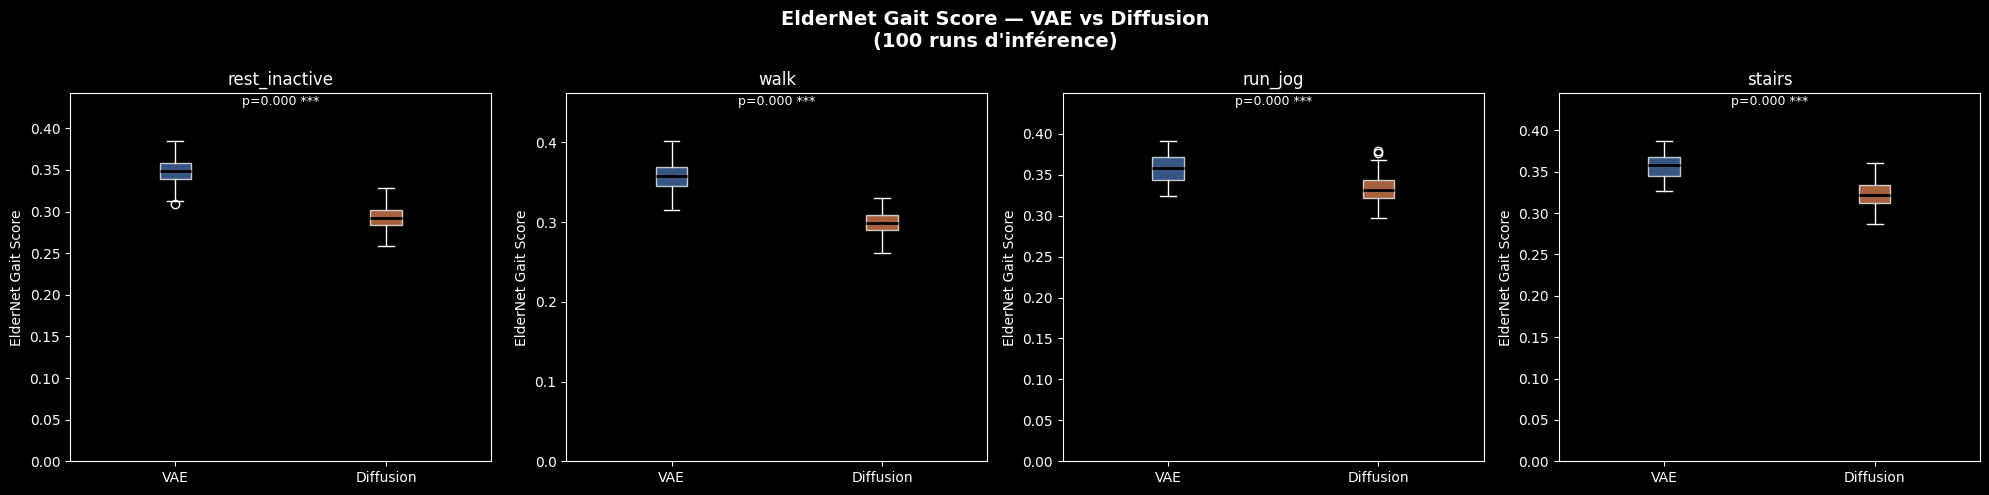

C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([vae_s, diff_s], labels=['VAE', 'Diff'],
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([vae_s, diff_s], labels=['VAE', 'Diff'],
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([vae_s, diff_s], labels=['VAE', 'Diff'],
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:68: MatplotlibDeprecationWarning: The 'labels' parameter

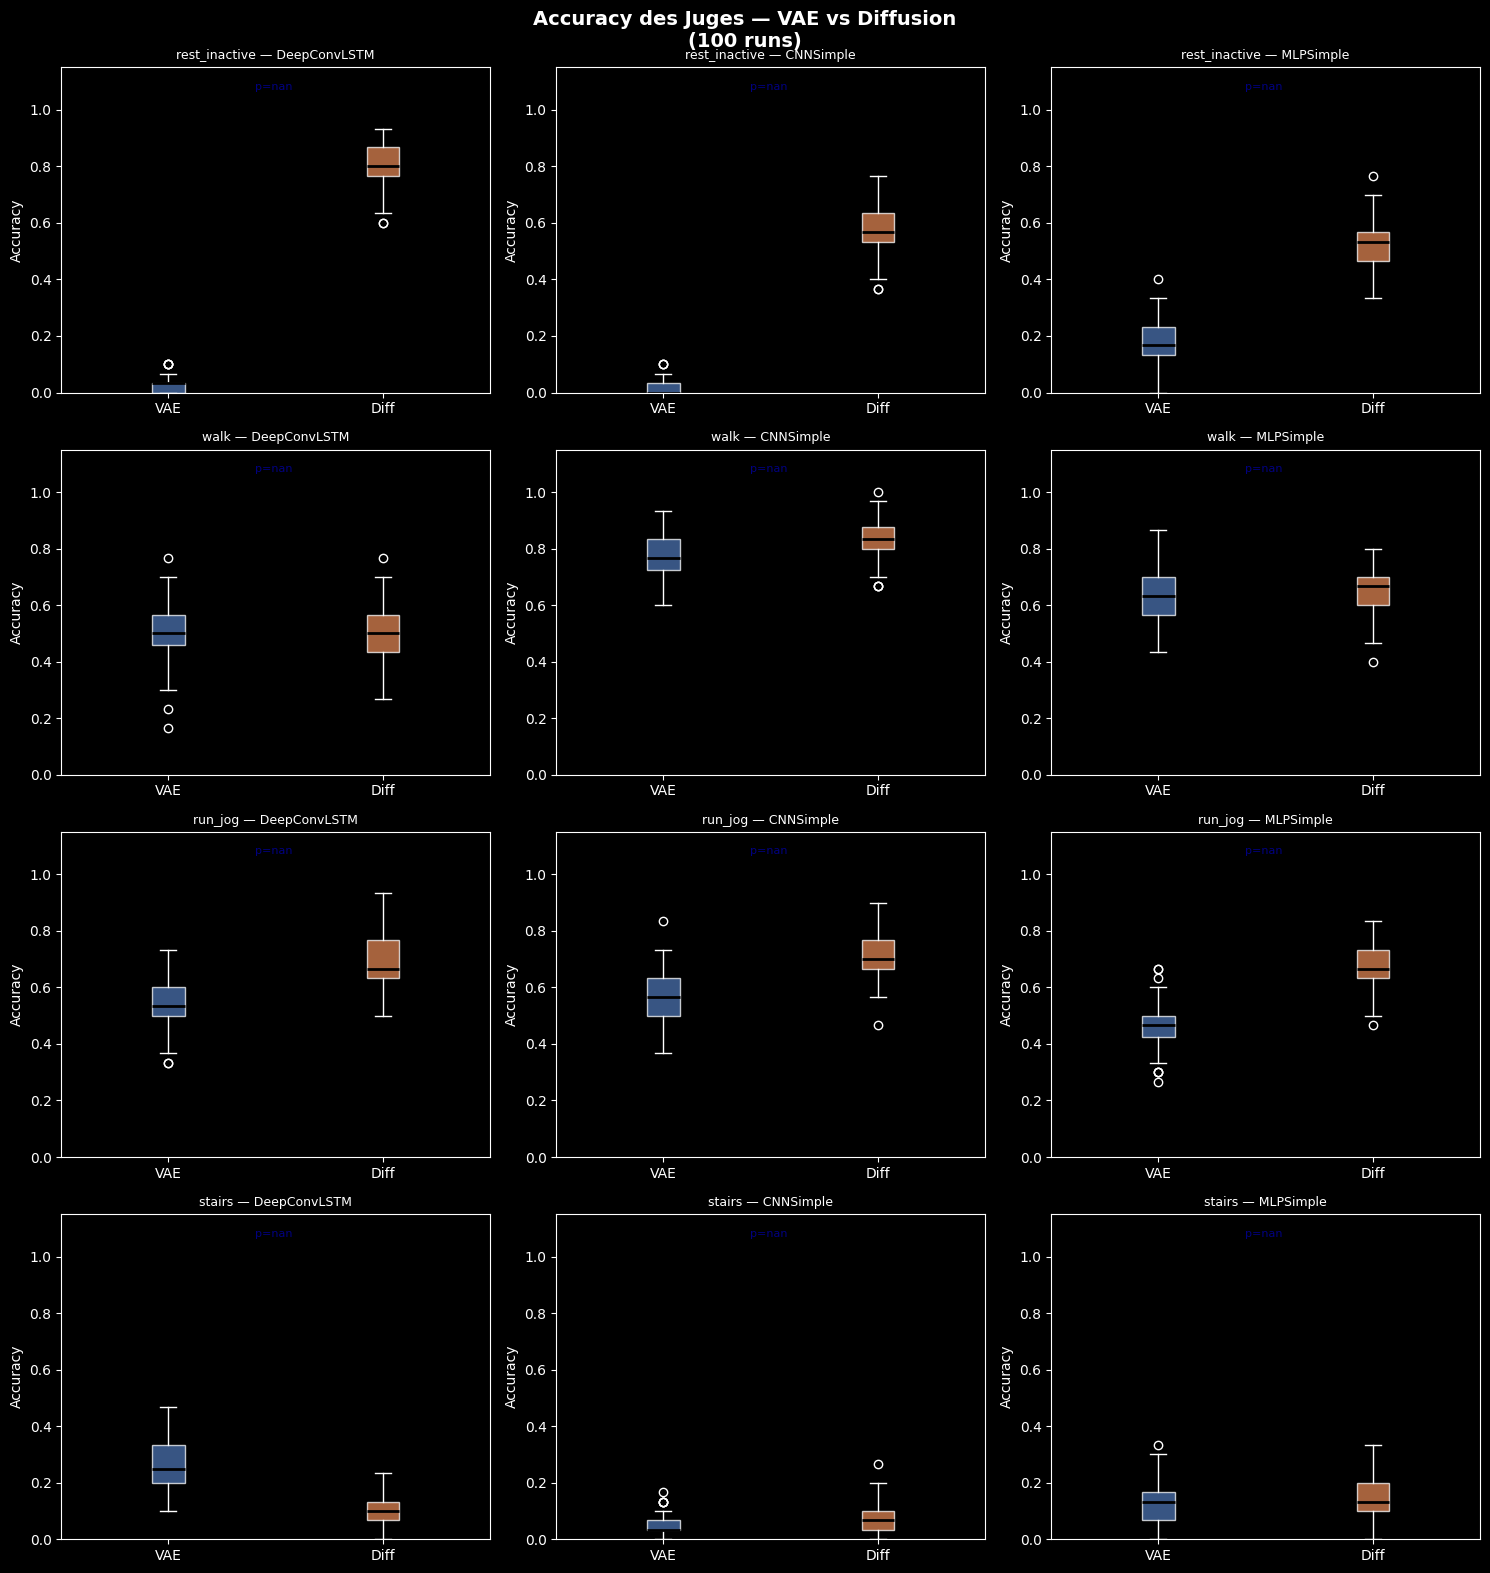

C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:104: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(df_heat.values, aspect='auto', cmap=cmap, vmin=0, vmax=0.1)
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3700910994.py:104: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(df_heat.values, aspect='auto', cmap=cmap, vmin=0, vmax=0.1)


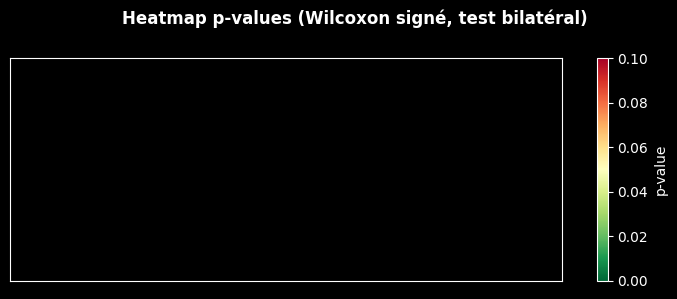

In [14]:
# =========================================================
# 14. VISUALISATIONS COMPARATIVES
# =========================================================

label_names = []
for cls in range(n_classes):
    old = inv_label_mapping[cls]
    label_names.append({0:'rest_inactive', 2:'walk', 3:'run_jog', 4:'stairs'}.get(old, f'Label {old}'))

colors_vae  = '#4C72B0'
colors_diff = '#DD8452'


# ── Figure 1 : ElderNet Gait Score par classe ─────────────────────────────

fig, axes = plt.subplots(1, n_classes, figsize=(5*n_classes, 5), sharey=False)
fig.suptitle("ElderNet Gait Score — VAE vs Diffusion\n(100 runs d'inférence)",
             fontsize=14, fontweight='bold')

for cls, ax in enumerate(axes):
    gait_v = extract_series('vae',  cls, lambda r: r['gait_score_mag'])
    gait_d = extract_series('diff', cls, lambda r: r['gait_score_mag'])

    bp = ax.boxplot(
        [gait_v, gait_d],
        labels=['VAE', 'Diffusion'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        notch=False,
    )
    for patch, color in zip(bp['boxes'], [colors_vae, colors_diff]):
        patch.set_facecolor(color); patch.set_alpha(0.75)

    row = df_stats[(df_stats.label == label_names[cls]) & (df_stats.metric == 'GaitScore(VAE_vs_Diff)')]
    sig = row['sig'].values[0] if len(row) else ''
    pval = row['p_value'].values[0] if len(row) else float('nan')

    ymax = max(max(gait_v), max(gait_d)) * 1.15
    ax.set_ylim(0, ymax)
    ax.set_title(label_names[cls])
    ax.set_ylabel("ElderNet Gait Score")

    # annotation p-value
    x1, x2 = 1, 2
    y  = ymax * 0.93
    ax.plot([x1, x1, x2, x2], [y, y+ymax*0.02, y+ymax*0.02, y], lw=1.5, c='k')
    ax.text((x1+x2)/2, y+ymax*0.03, f"p={pval:.3f} {sig}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("gait_score_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2 : Accuracy juges par classe ─────────────────────────────────

fig, axes = plt.subplots(n_classes, len(judge_names),
                         figsize=(5*len(judge_names), 4*n_classes))
fig.suptitle("Accuracy des Juges — VAE vs Diffusion\n(100 runs)",
             fontsize=14, fontweight='bold')

for ci, cls in enumerate(range(n_classes)):
    for ji, jname in enumerate(judge_names):
        ax = axes[ci][ji]
        vae_s  = extract_series('vae',  cls, lambda r, j=jname: r['judge_res'][j]['acc'])
        diff_s = extract_series('diff', cls, lambda r, j=jname: r['judge_res'][j]['acc'])

        bp = ax.boxplot([vae_s, diff_s], labels=['VAE', 'Diff'],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], [colors_vae, colors_diff]):
            patch.set_facecolor(c); patch.set_alpha(0.75)

        row = df_stats[
            (df_stats.label == label_names[cls]) &
            (df_stats.metric == f'JudgeAcc_{jname}')
        ]
        sig  = row['sig'].values[0]  if len(row) else ''
        pval = row['p_value'].values[0] if len(row) else float('nan')

        ax.set_title(f"{label_names[cls]} — {jname}", fontsize=9)
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1.15)
        ax.text(1.5, 1.07, f"p={pval:.3f} {sig}",
                ha='center', fontsize=8, color='navy')

plt.tight_layout()
plt.savefig("judge_accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 3 : heatmap récapitulative p-values ───────────────────────────

# On filtre les métriques clés pour la heatmap
key_metrics = ['GaitScore(ElderNet)'] + [f'JudgeAcc_{j}' for j in judge_names]
df_heat = df_stats[df_stats.metric.isin(key_metrics)].copy()
df_heat = df_heat.pivot(index='label', columns='metric', values='p_value')

fig, ax = plt.subplots(figsize=(max(6, len(key_metrics)*1.8), 3))
fig.suptitle("Heatmap p-values (Wilcoxon signé, test bilatéral)", fontsize=12, fontweight='bold')

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn_r
im = ax.imshow(df_heat.values, aspect='auto', cmap=cmap, vmin=0, vmax=0.1)
ax.set_xticks(range(len(df_heat.columns)))
ax.set_xticklabels(df_heat.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(df_heat.index)))
ax.set_yticklabels(df_heat.index)

for i in range(len(df_heat.index)):
    for j in range(len(df_heat.columns)):
        val = df_heat.values[i, j]
        sig = '***' if val < 0.001 else ('**' if val < 0.01 else ('*' if val < 0.05 else 'ns'))
        ax.text(j, i, f"{val:.3f}\n{sig}", ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, label='p-value')
plt.tight_layout()
plt.savefig("pvalue_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# =========================================================
# 15. ANALYSE PAR AXES (X, Y, Z) — ElderNet Gait Score 3D
# =========================================================
#
# Les signaux générés sont en espace magnitude normalisé.
# Pour exploiter les 3 axes lors de l'évaluation, on utilise
# les VRAIS signaux 3 axes du jeu de test pour :
#   - calculer le score de référence (données réelles)
#   - comparer avec la distribution générée (qualité relative)
#
# Cela permet de caractériser si les modèles génèrent des signaux
# dont la régularité est cohérente avec les vrais signaux par axe.

def gait_score_reference_3ax(cls):
    """Score ElderNet moyen sur les vraies données test, classe cls, 3 axes."""
    mask = y_test == cls
    wins = X_3ax_test_n[mask]  # (N, 50, 3)
    if len(wins) == 0: return float('nan')
    return eldernet_gait_score_3ax(wins)

print("\n════ ELDERNET GAIT SCORE 3 AXES — DONNÉES RÉELLES (RÉFÉRENCE) ════")
ref_scores = {}
for cls in range(n_classes):
    ref_scores[cls] = gait_score_reference_3ax(cls)
    lname = label_names[cls]
    print(f"  {lname} : {ref_scores[cls]:.4f}")


# Score 3 axes VAE et Diffusion sur les signaux générés
# Note : les modèles génèrent la magnitude — pour la comparaison
# on projette le signal généré sur un "axe virtuel" (répété 3 fois)
# ou on utilise la magnitude seule et l'on compare à la référence 3D.
# On documente cette distinction ici.

print("\n════ COMPARAISON GAIT SCORE (généré magnitude vs réel 3 axes) ════")
print(f"{'Classe':<12} {'Modèle':<12} {'Score généré':<16} {'Réf 3 axes':<14} {'Δ (abs)'}")
print("-" * 65)

for cls in range(n_classes):
    for mtype in ['vae', 'diff', 'gan']:
        gait_series = extract_series(mtype, cls, lambda r: r['gait_score_mag'])
        mean_gen = np.mean(gait_series)
        ref      = ref_scores[cls]
        delta    = abs(mean_gen - ref)
        print(f"{label_names[cls]:<12} {mtype.upper():<12} {mean_gen:.4f}           {ref:.4f}       {delta:.4f}")


════ ELDERNET GAIT SCORE 3 AXES — DONNÉES RÉELLES (RÉFÉRENCE) ════
  rest_inactive : 0.1317
  walk : 0.1338
  run_jog : 0.2900
  stairs : 0.1544

════ COMPARAISON GAIT SCORE (généré magnitude vs réel 3 axes) ════
Classe       Modèle       Score généré     Réf 3 axes     Δ (abs)
-----------------------------------------------------------------
rest_inactive VAE          0.3492           0.1317       0.2174
rest_inactive DIFF         0.2919           0.1317       0.1602
rest_inactive GAN          0.2664           0.1317       0.1346
walk         VAE          0.3569           0.1338       0.2230
walk         DIFF         0.2995           0.1338       0.1657
walk         GAN          0.3413           0.1338       0.2075
run_jog      VAE          0.3572           0.2900       0.0672
run_jog      DIFF         0.3326           0.2900       0.0426
run_jog      GAN          0.3704           0.2900       0.0804
stairs       VAE          0.3575           0.1544       0.2031
stairs       DIFF    

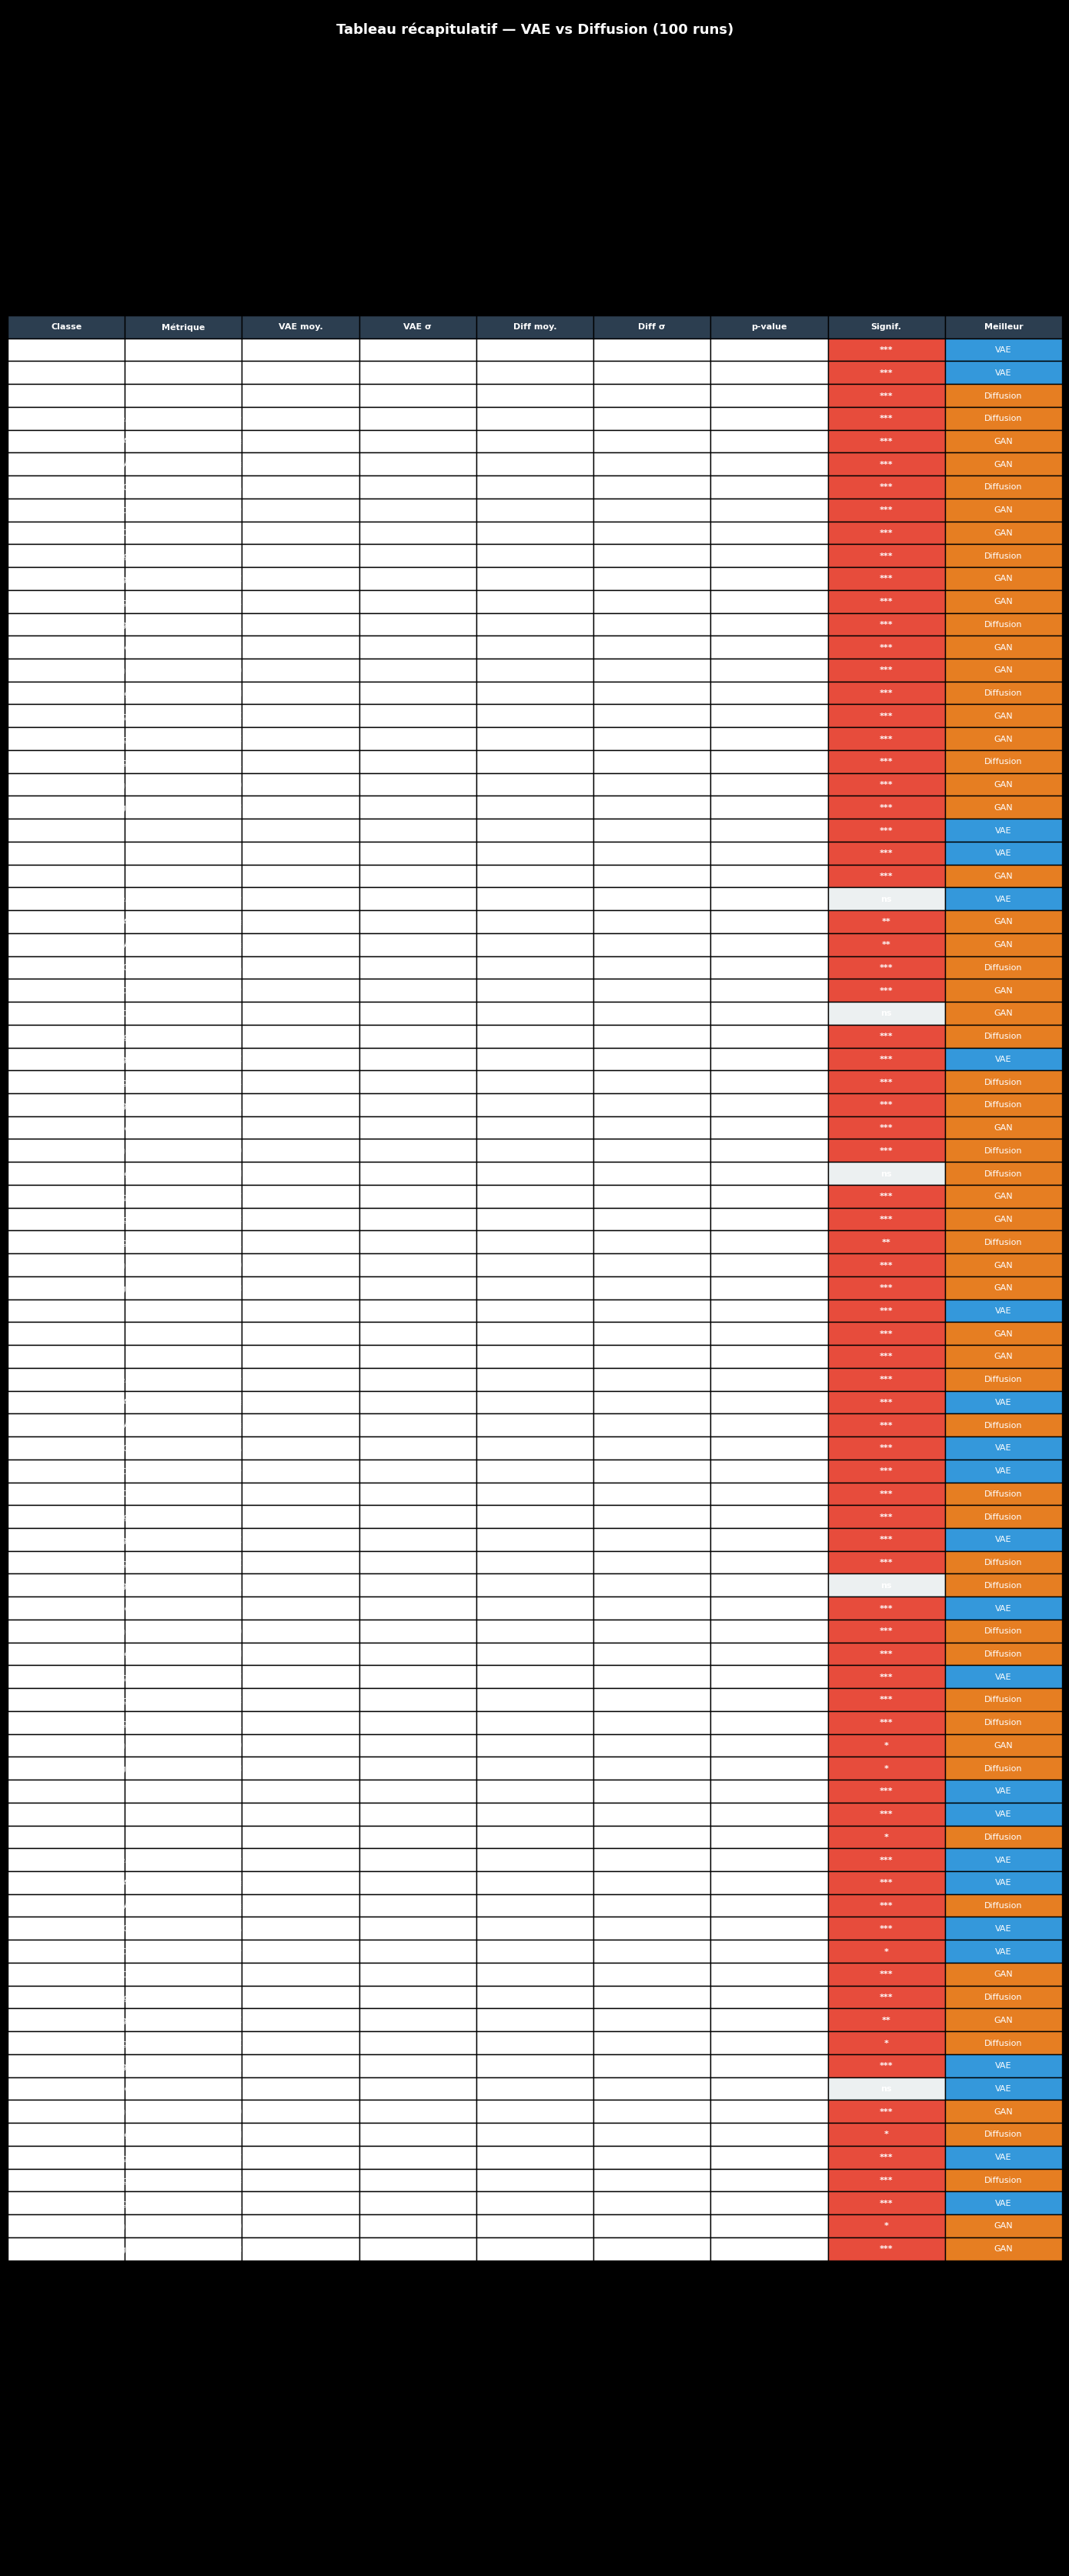


✅ Analyse complète terminée.


In [16]:
# =========================================================
# 16. FIGURE DE SYNTHÈSE — TABLEAU RÉCAPITULATIF
# =========================================================

fig, ax = plt.subplots(figsize=(14, len(df_stats)*0.38 + 2))
ax.axis('off')
fig.suptitle("Tableau récapitulatif — VAE vs Diffusion (100 runs)",
             fontsize=13, fontweight='bold', y=0.98)

cols = ['label', 'metric',
        'vae_mean', 'vae_std', 'diff_mean', 'diff_std',
        'p_value', 'sig', 'better']

col_labels = ['Classe', 'Métrique',
              'VAE moy.', 'VAE σ', 'Diff moy.', 'Diff σ',
              'p-value', 'Signif.', 'Meilleur']

cell_data = []
for _, row in df_stats[cols].iterrows():
    cell_data.append([
        row['label'], row['metric'],
        f"{row['vae_mean']:.4f}", f"{row['vae_std']:.4f}",
        f"{row['diff_mean']:.4f}", f"{row['diff_std']:.4f}",
        f"{row['p_value']:.4f}", row['sig'], row['better'],
    ])

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)

# Colorer les cellules 'sig'
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 7 and r > 0:  # colonne sig
        v = cell_data[r-1][7]
        cell.set_facecolor('#e74c3c' if v != 'ns' else '#ecf0f1')
        cell.set_text_props(fontweight='bold')
    elif c == 8 and r > 0:  # colonne better
        v = cell_data[r-1][8]
        cell.set_facecolor('#3498db' if v == 'VAE' else '#e67e22')
        cell.set_text_props(color='white')

plt.tight_layout()
plt.savefig("summary_table.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Analyse complète terminée.")

C:\Users\adril\AppData\Local\Temp\ipykernel_196\3642996892.py:65: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f"expert_validation_{nom_activite}_3models.png", dpi=120, bbox_inches='tight')
C:\Users\adril\AppData\Local\Temp\ipykernel_196\3642996892.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f"expert_validation_{nom_activite}_3models.png", dpi=120, bbox_inches='tight')
D:\IMDS\MALMO\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
D:\IMDS\MALMO\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


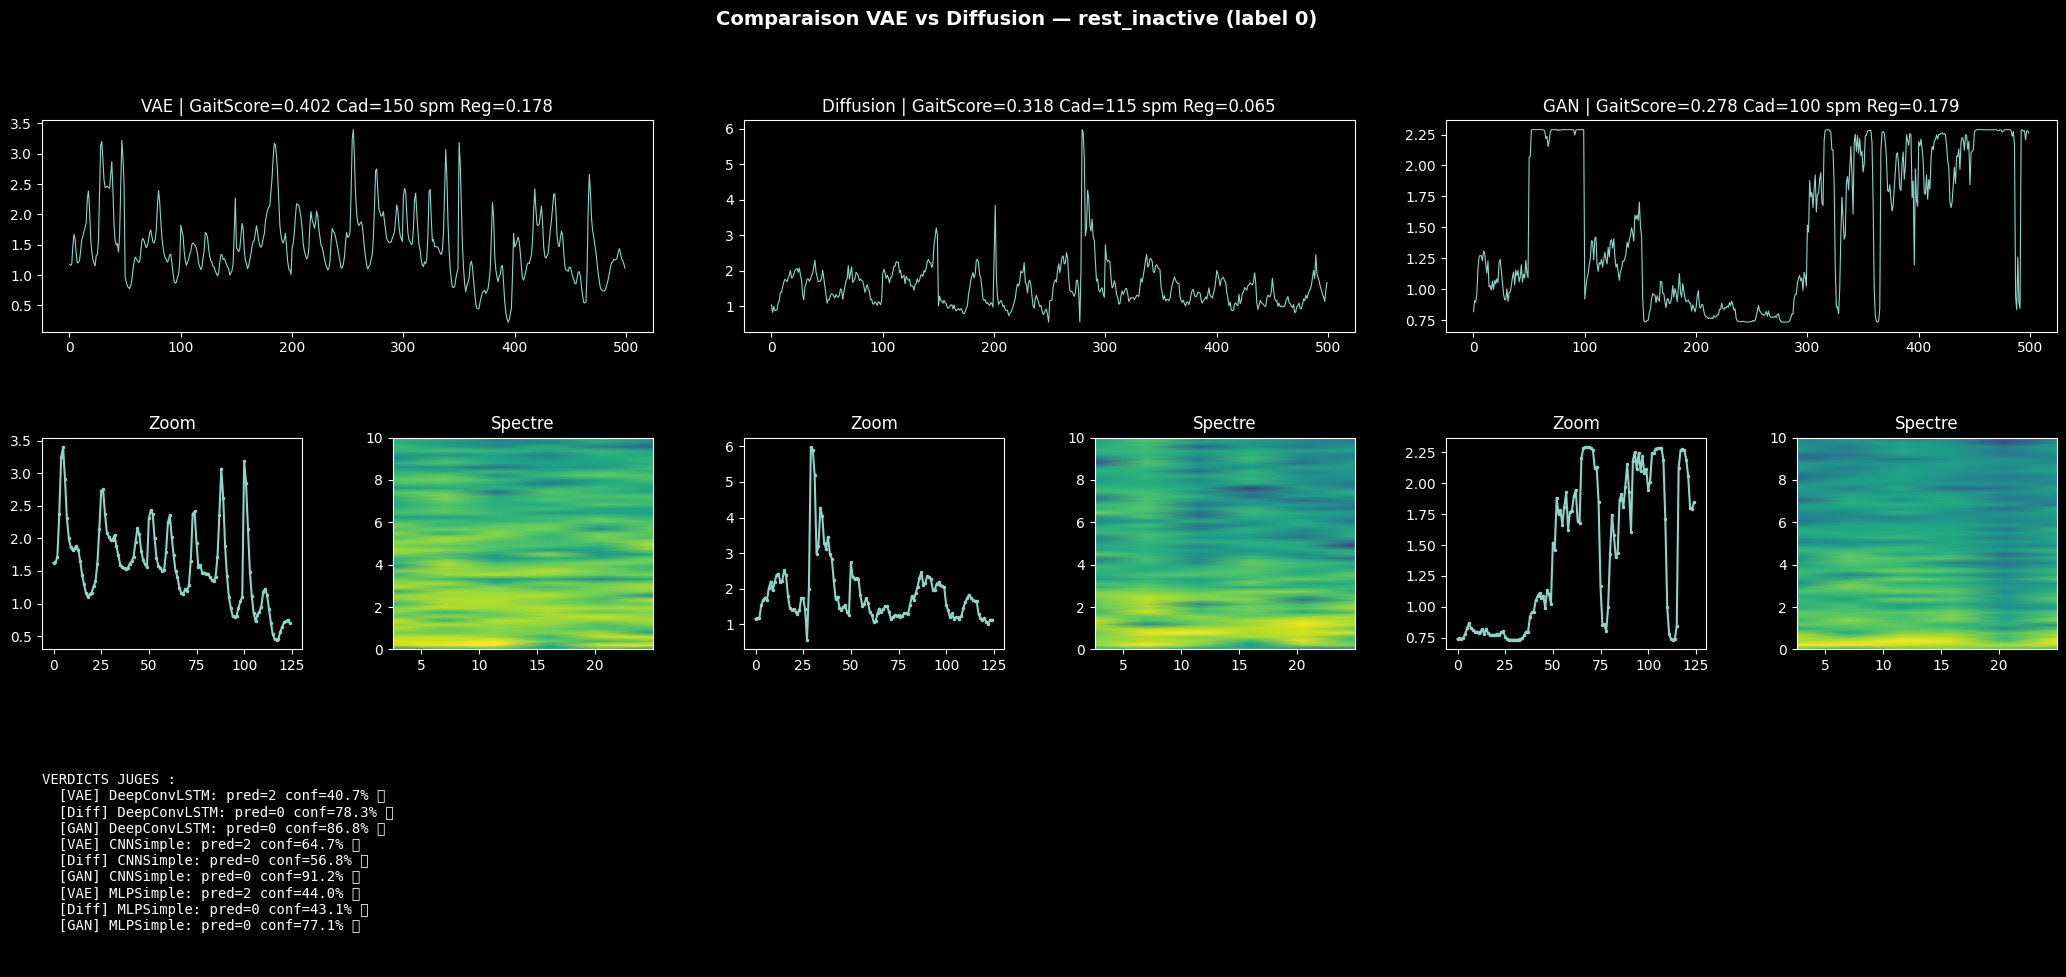

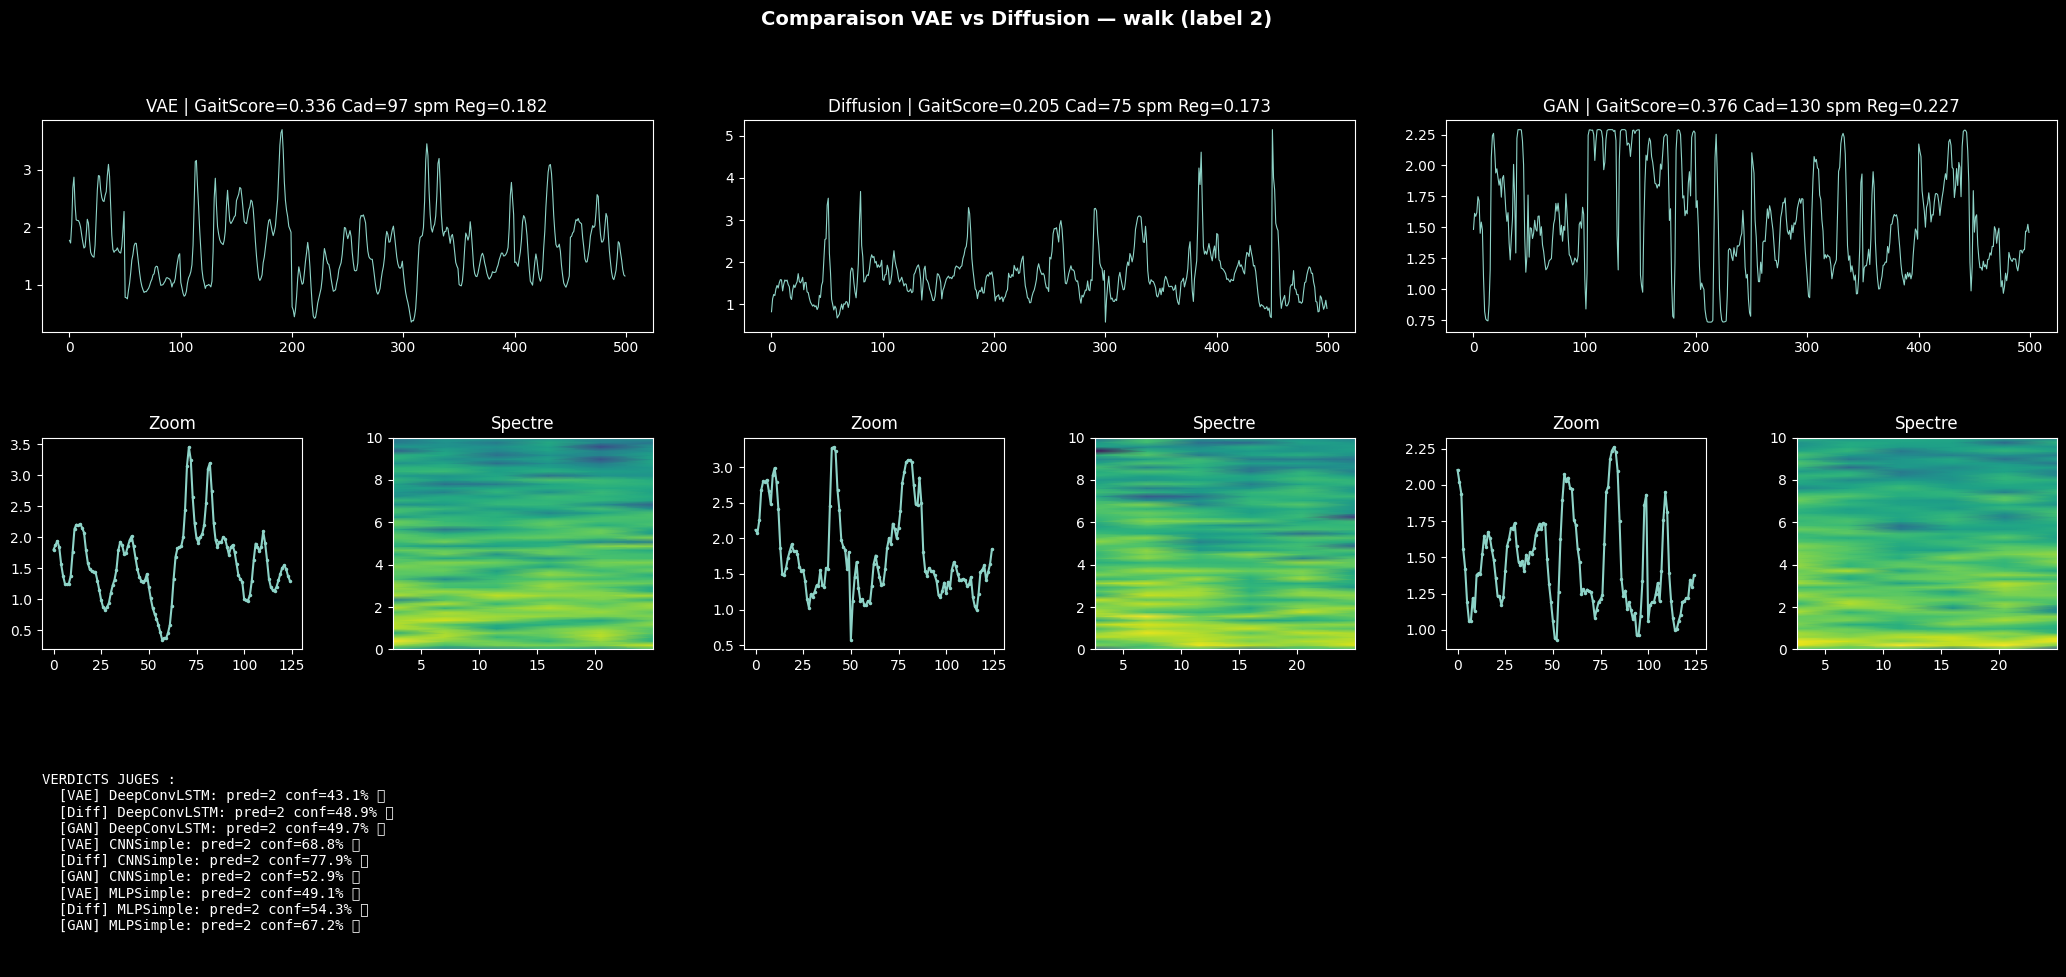

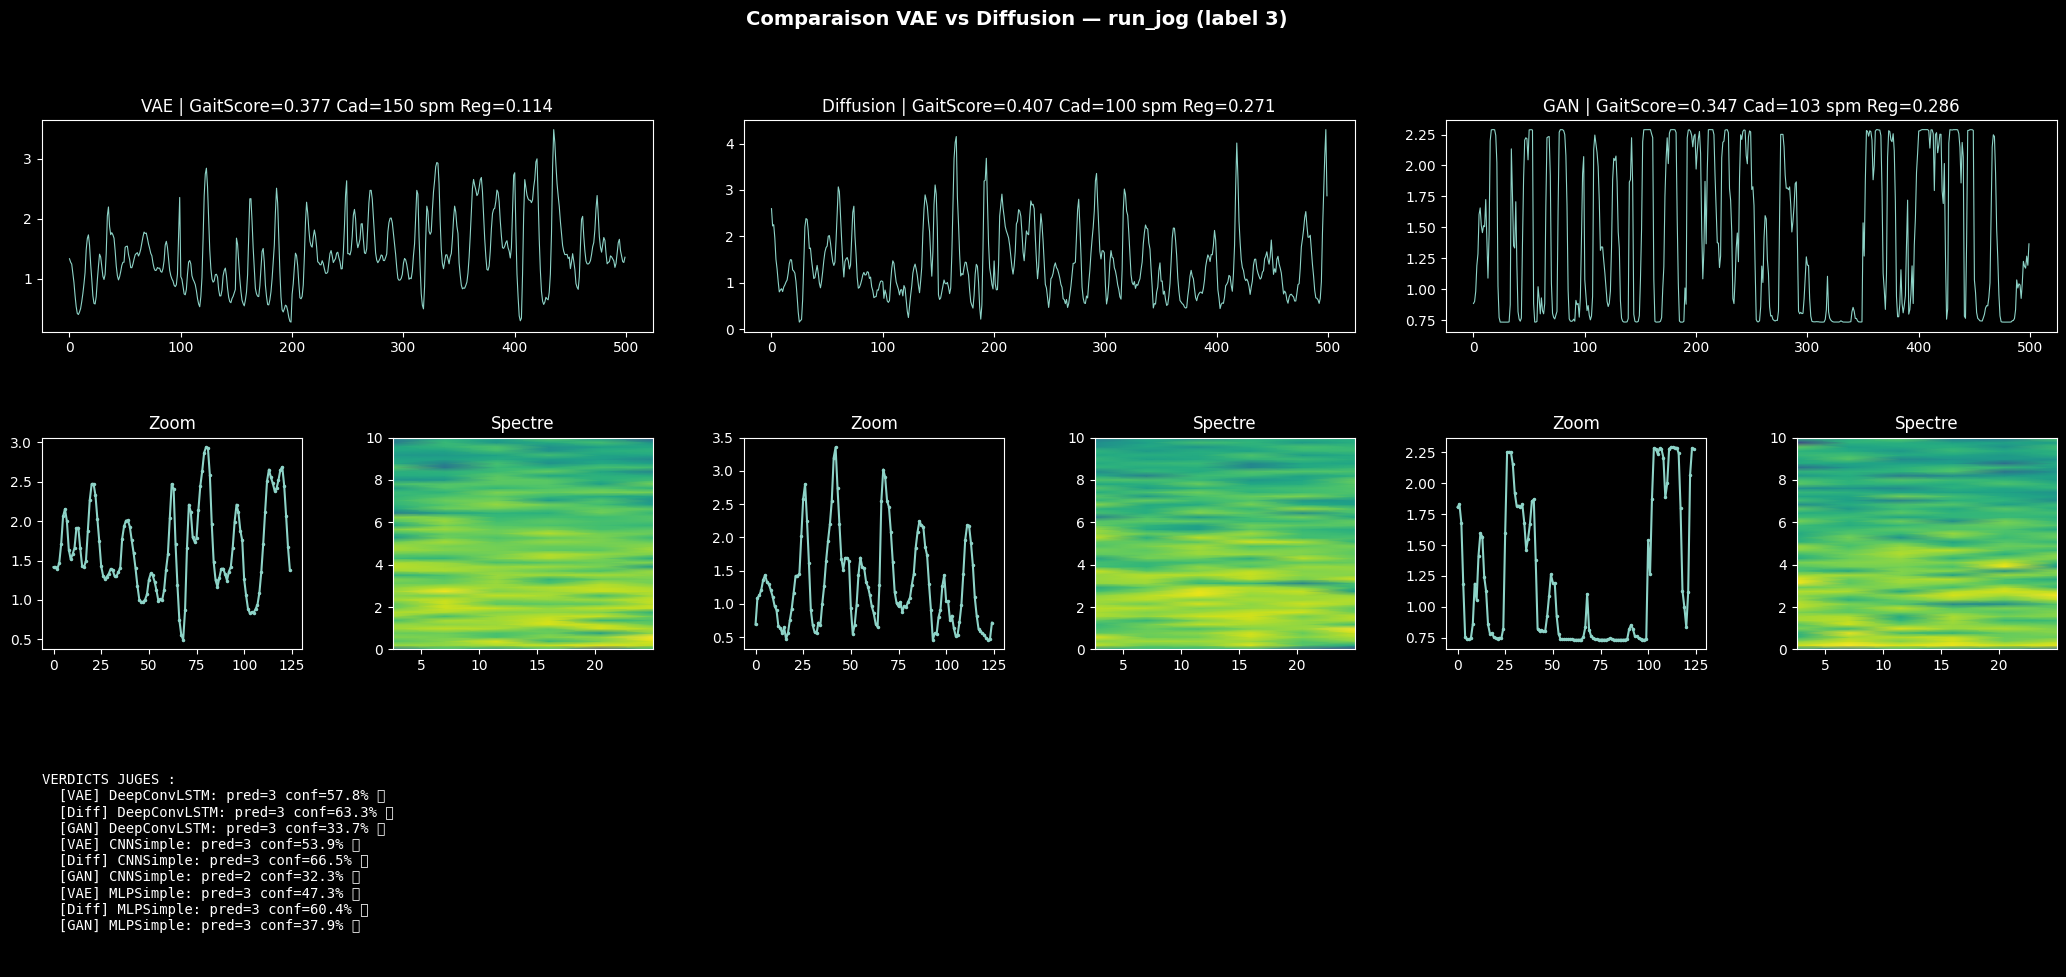

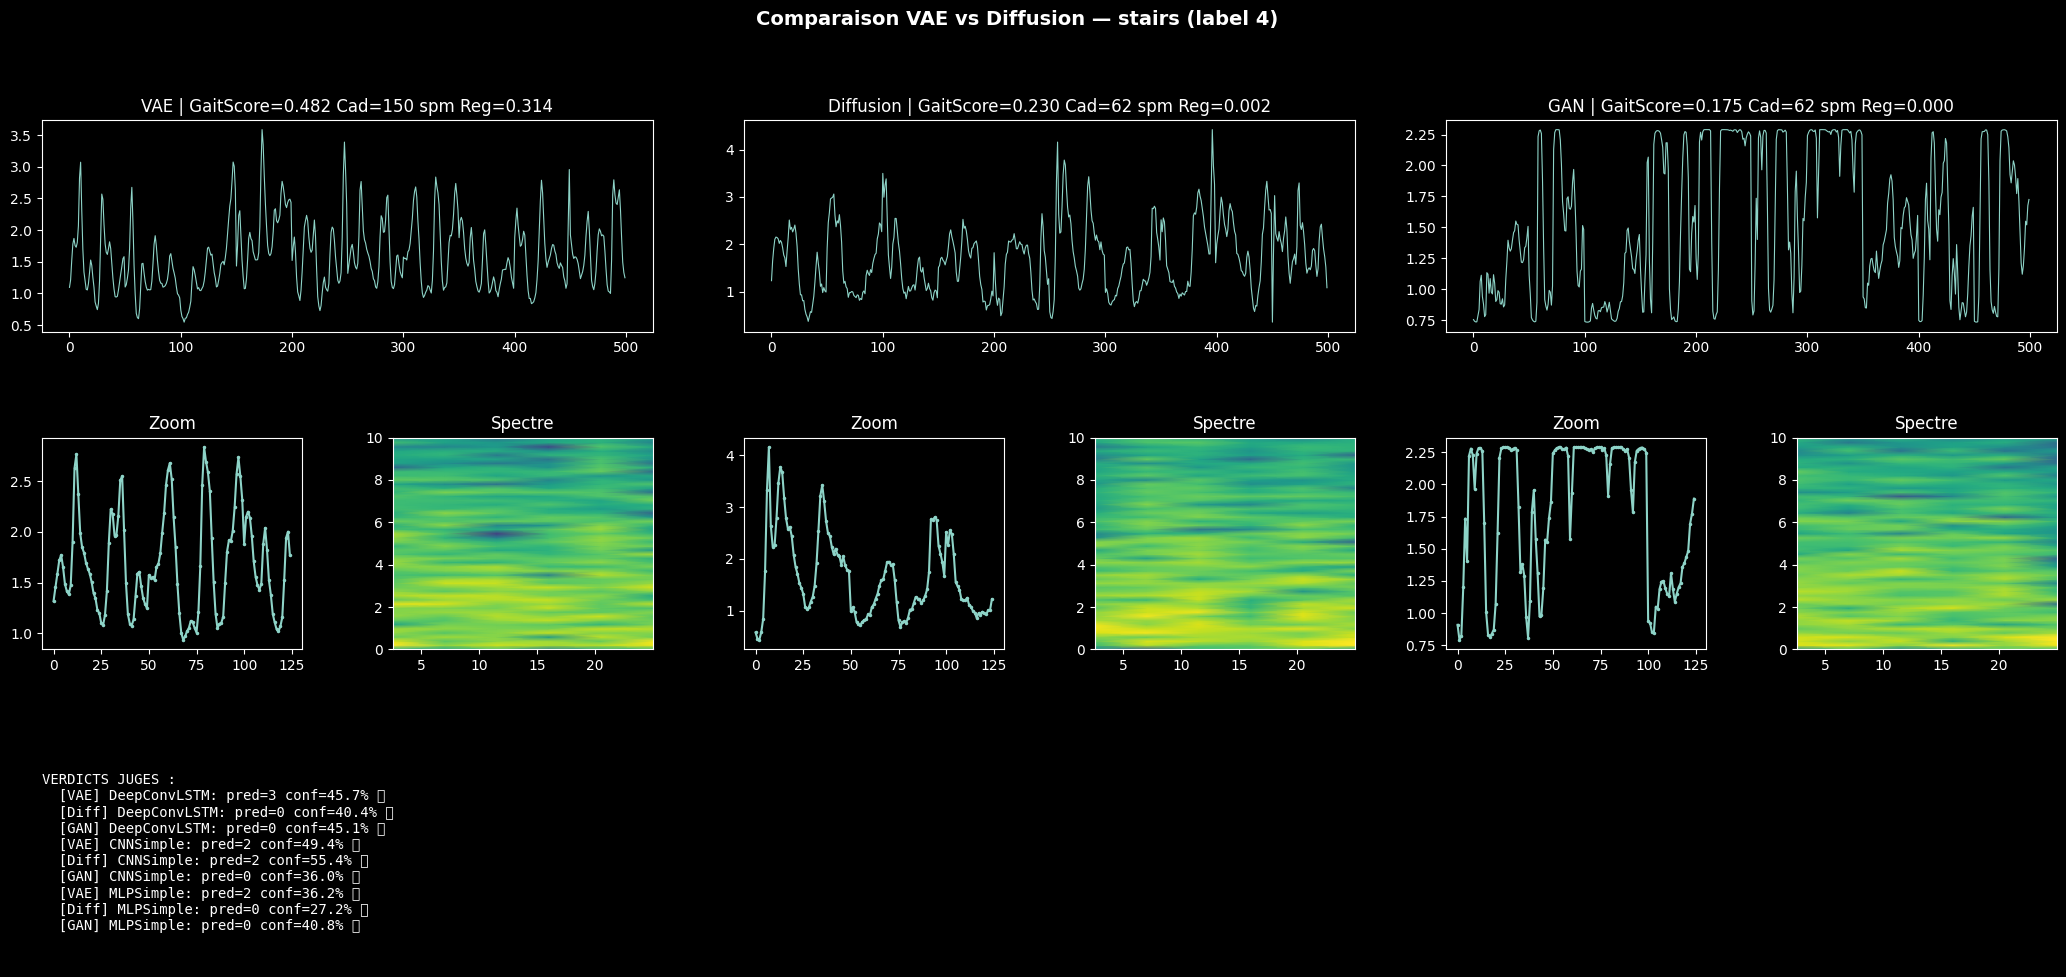

In [17]:
# =========================================================
# 17. VALIDATION EXPERTE — EXEMPLES VISUELS
# =========================================================
# (Identique aux originaux, adapté pour afficher VAE ET Diffusion
#  côte à côte pour comparaison qualitative.)

def expert_validation_compare(old_label_id, nom_activite):
    mapped = label_mapping[old_label_id]

    # ── Génération ────────────────────────────────────────────────────────────
    gen_vae  = vae_model.sample(30, mapped, device)          # (30, 1, 50)
    gen_diff = diff_context.sample(diff_model, 30, mapped)   # (30, 1, 50)
    gen_gan  = gan_gen.sample(30, mapped, device)            # (30, 1, 50)

    def to_np_phys(gen_t):
        return denorm_mag(gen_t.cpu().numpy())   # physique

    vae_phys  = to_np_phys(gen_vae)
    diff_phys = to_np_phys(gen_diff)

    fig = plt.figure(figsize=(26, 11))
    gs  = gridspec.GridSpec(3, 6, figure=fig, hspace=0.5, wspace=0.35)
    fig.suptitle(f"Comparaison VAE vs Diffusion — {nom_activite} (label {old_label_id})",
                 fontsize=14, fontweight='bold')

    gan_phys = to_np_phys(gen_gan)
    for col, (label_m, gen_phys, gen_t) in enumerate(
        [('VAE', vae_phys, gen_vae), ('Diffusion', diff_phys, gen_diff), ('GAN', gan_phys, gen_gan)]):

        full = gen_phys.flatten()

        # Signal
        ax_sig = fig.add_subplot(gs[0, col*2 : col*2+2])
        ax_sig.plot(full[:500], lw=0.8)
        gait_s, cad, reg = eldernet_gait_score(gen_t.cpu().numpy()[0], FS, return_details=True)
        ax_sig.set_title(f"{label_m} | GaitScore={gait_s:.3f} Cad={cad:.0f} spm Reg={reg:.3f}")

        # Zoom
        ax_z = fig.add_subplot(gs[1, col*2])
        ax_z.plot(full[250:375], marker='.', ms=3)
        ax_z.set_title("Zoom")

        # Spectre
        ax_sp = fig.add_subplot(gs[1, col*2+1])
        f_, t_, Sxx = scipy_signal.spectrogram(full, fs=FS)
        ax_sp.pcolormesh(t_, f_, 10*np.log10(Sxx+1e-7), shading='gouraud')
        ax_sp.set_ylim(0, 10); ax_sp.set_title("Spectre")

    # Juges (communs aux deux)
    ax_j = fig.add_subplot(gs[2, :])
    ax_j.axis('off')
    txt = "VERDICTS JUGES :\n"
    for judge in judges:
        judge.eval()
        with torch.no_grad():
            for label_m, gen_t in [('VAE', gen_vae), ('Diff', gen_diff), ('GAN', gen_gan)]:
                probs = torch.softmax(judge(gen_t), 1).mean(0)
                pred  = inv_label_mapping[probs.argmax().item()]
                conf  = probs.max().item() * 100
                ok    = '✅' if pred == old_label_id else '❌'
                txt  += (f"  [{label_m}] {judge.__class__.__name__}: "
                         f"pred={pred} conf={conf:.1f}% {ok}\n")
    ax_j.text(0, 0.5, txt, fontsize=10, family='monospace', va='center')

    plt.savefig(f"expert_validation_{nom_activite}_3models.png", dpi=120, bbox_inches='tight')
    plt.show()


# Génération pour toutes les classes
activity_names = {0: 'rest_inactive', 2: 'walk', 3: 'run_jog', 4: 'stairs'}
for old_lbl in label_mapping.keys():
    name = activity_names.get(old_lbl, f'Activity_{old_lbl}')
    expert_validation_compare(old_lbl, name)

In [18]:
# =========================================================
# 18. EXPORT DES RÉSULTATS
# =========================================================

df_stats.to_csv("resultats_vae_diffusion_gan.csv", index=False)
print("Résultats exportés dans resultats_vae_diffusion_gan.csv")

# Résumé par modèle
print("\n════ BILAN GLOBAL ════")
for mtype_label in ['VAE', 'Diffusion', 'GAN']:
    wins = (df_stats['better'] == mtype_label).sum()
    sig_wins = ((df_stats['better'] == mtype_label) & (df_stats['sig'] != 'ns')).sum()
    print(f"  {mtype_label} : meilleur sur {wins}/{len(df_stats)} métriques "
          f"({sig_wins} significatives)")

Résultats exportés dans resultats_vae_diffusion_gan.csv

════ BILAN GLOBAL ════
  VAE : meilleur sur 23/84 métriques (21 significatives)
  Diffusion : meilleur sur 31/84 métriques (29 significatives)
  GAN : meilleur sur 30/84 métriques (29 significatives)
